#  Fine-Tuning BERT for News Topic Classification

##  Problem Statement
In modern NLP systems, understanding and categorizing news articles into meaningful topics is a fundamental task used in:
- search engines
- recommendation systems
- content moderation
- news aggregation platforms

This project focuses on building a **high-performance text classification system** using a pretrained transformer model: **BERT**.

##  Why This Problem Matters
News data is:
- unstructured
- high-dimensional
- semantically ambiguous

Traditional ML models (SVM, Naive Bayes) fail to capture:
- contextual meaning
- long-range dependencies
- semantic relationships

##  Solution Approach
We fine-tune a pretrained transformer model:
> **BERT (Bidirectional Encoder Representations from Transformers)**
Fine-tuning allows us to:
- reuse pretrained linguistic knowledge
- adapt to AG News dataset
- achieve high accuracy with minimal training cost

##  Goal
Train a model that classifies news into:
- World 
- Sports   
- Business   
- Sci/Tech 

#  Environment Setup for Transformer-Based NLP Training

##  Overview
Modern NLP systems rely on a complex ecosystem of libraries that handle:
- pretrained transformer models
- dataset management
- optimization engines
- evaluation metrics
- deployment interfaces

This project uses the Hugging Face ecosystem, which has become the de-facto standard for transformer-based machine learning workflows.


##  Why these libraries matter

- `transformers`: provides pretrained architectures like BERT, GPT, T5
- `datasets`: efficient dataset streaming and memory mapping
- `accelerate`: hardware-aware training optimization
- `evaluate`: standardized metric computation
- `scikit-learn`: classical ML evaluation tools
- `gradio / streamlit`: deployment interfaces

##  Version control importance
We explicitly pin `transformers==4.52.4` to ensure:
- reproducibility
- stable API behavior
- consistent tokenizer/model outputs

Even minor version differences in transformer libraries can affect:
- tokenization behavior
- model loading architecture
- training stability

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn matplotlib seaborn streamlit gradio huggingface_hub
!pip install transformers==4.52.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 104.1 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 113.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.8.0
    Uninstalling transformers-5.8.0:
      Successfully uninstalled transformers-5.8.0


#  Library Verification and Runtime Integrity Check

##  Purpose
Before training deep learning models, it is essential to verify:
- correct package versions
- proper installation
- no conflicting dependencies

##  Why this matters in ML systems
Transformer models depend heavily on:
- CUDA compatibility
- tokenizer versions
- model serialization formats

A mismatch can lead to:
- silent performance degradation
- training instability
- inference errors

In [2]:
import transformers

print(transformers.__version__)
print(transformers.__file__)

4.52.4
/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


#  Core NLP + Deep Learning Stack Initialization

##  Purpose

This cell initializes all required components for:
- dataset processing
- model training
- evaluation
- visualization
- inference

##  Why multiple libraries?
Modern NLP pipelines are not single-model systems.
They are **multi-component architectures** involving:
- data pipelines (datasets)
- neural networks (transformers + torch)
- evaluation frameworks (sklearn + evaluate)
- visualization layers (matplotlib + seaborn)

In [3]:
import numpy as np
import pandas as pd
import torch
import evaluate
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

#  Hardware Acceleration Layer (GPU Detection)

##  Why GPU matters
Transformer models like BERT contain:
- 110M+ parameters
- matrix multiplications at every layer

CPU training would be:
- extremely slow
- computationally inefficient

##  CUDA Acceleration
We use NVIDIA CUDA GPUs (Tesla T4 in this case) to:
- parallelize tensor operations
- speed up matrix multiplications
- reduce training time from hours → minutes

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU: Tesla T4


#  AG News Dataset: Large-Scale Text Classification Benchmark

##  Dataset Overview
The AG News dataset is a widely used benchmark in NLP research containing:
- 120,000 training samples
- 7,600 test samples

Each sample consists of:
- news article text
- label (4-class classification)


##  Why this dataset is important
It is designed to test:
- semantic understanding
- topic classification ability
- generalization of language models

##  Class Distribution
The dataset is perfectly balanced:
- 30,000 samples per class

This ensures unbiased model evaluation.

In [5]:
dataset = load_dataset("ag_news")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

#  Dataset Inspection

##  Why inspect raw samples?
Before preprocessing, we must understand:
- text structure
- label encoding
- noise patterns

This helps avoid:
- preprocessing errors
- label mismatch bugs

In [6]:
dataset["train"][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

#  Label Encoding Strategy

##  Why mapping is required
Machine learning models cannot understand string labels.

We convert:
World → 0
Sports → 1
Business → 2
Sci/Tech → 3

##  Why both mappings?

- `id2label` → for interpretability
- `label2id` → for training consistency

In [7]:
id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

label2id = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Sci/Tech": 3
}

#  Tokenizer: Converting Language into Neural Representations

##  What is a tokenizer?
A tokenizer is a transformation system that converts:
> human-readable text → numerical tokens

##  Why BERT tokenizer?
We use:
- WordPiece tokenization
- subword decomposition
- fixed vocabulary (30,522 tokens)

##  Why uncased model?
"uncased" means:
- ignores capitalization
- reduces vocabulary complexity

In [8]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

#  Tokenization Pipeline Design

##  Objective
Convert raw text into:
- input_ids
- attention_mask

##  Key transformations
- padding → ensures fixed input size
- truncation → prevents overflow
- max_length → controls computational cost

##  Why 128 tokens?
Balanced tradeoff between:
- context coverage
- GPU efficiency

In [9]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

#  Dataset Encoding Pipeline

##  What is happening?
We transform entire dataset into model-ready tensors.

This is a critical step because:
- raw text cannot be processed directly
- transformers require numerical tensors

In [10]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

#  PyTorch Tensor Conversion Layer

##  Why format data?

We convert dataset into PyTorch format for:
- GPU acceleration
- batching efficiency
- compatibility with Trainer API

In [11]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

#  BERT Fine-Tuning Architecture

##  What is happening?
We take pretrained BERT and add:
> classification head for 4-class prediction

##  Internal structure
- Embedding layer
- 12 transformer encoder layers
- pooled [CLS] token representation
- linear classification head

##  Why fine-tuning works
Because BERT already learned:
- grammar
- semantics
- context relationships

We only adapt it to news classification.

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

#  Evaluation Metrics System

##  Why multiple metrics?
Accuracy alone is insufficient.

We also use:
- F1-score → balances precision & recall
- weighted averaging → handles class balance

##  Why evaluate library?

Standardizes metric computation across models.

In [15]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

#  Model Evaluation Function

##  Purpose
Convert raw logits into interpretable performance metrics.

##  Pipeline
logits → softmax → predictions → metrics

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )
    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

#  Training Configuration Strategy

##  What is TrainingArguments?
It defines the entire training behavior:
- optimization strategy
- logging frequency
- checkpointing rules
- evaluation schedule

##  Key design choices
- FP16 → faster training
- early stopping → prevents overfitting
- save best model → ensures optimal checkpoint

In [19]:
training_args = TrainingArguments(
    output_dir="./outputs/checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./outputs/logs",
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

#  Trainer Engine: Automated Deep Learning Pipeline

##  What is Trainer?
Trainer is a high-level abstraction that handles:
- forward pass
- backward propagation
- optimization
- evaluation
- checkpointing

##  Why it matters
Without Trainer, we would manually implement:
- training loops
- GPU synchronization
- gradient updates

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)


#  Model Training Process

##  What happens during training?
For each batch:
1. forward pass
2. loss computation
3. gradient calculation
4. weight update

##  Observation
We observe:
- decreasing training loss
- stable validation performance
- no severe overfitting

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.186000,0.184931,0.943289,0.943283
2,0.115400,0.190248,0.948158,0.948201
3,0.080900,0.232017,0.946579,0.946609


TrainOutput(global_step=22500, training_loss=0.14773574142456056, metrics={'train_runtime': 2996.0455, 'train_samples_per_second': 120.158, 'train_steps_per_second': 7.51, 'total_flos': 2.368042020864e+16, 'train_loss': 0.14773574142456056, 'epoch': 3.0})

#  Final Model Evaluation

##  What this tells us
Evaluation measures:
- generalization ability
- unseen data performance
- real-world robustness

##  Key metrics interpretation
- loss → prediction error
- accuracy → correctness
- F1 → balanced performance

In [22]:
results = trainer.evaluate()
results

{'eval_loss': 0.19024811685085297,
 'eval_accuracy': 0.9481578947368421,
 'eval_f1': 0.9482012044944137,
 'eval_runtime': 14.0268,
 'eval_samples_per_second': 541.82,
 'eval_steps_per_second': 33.864,
 'epoch': 3.0}

#  Model Persistence Layer

##  Why saving matters
Once trained, models must be stored for:
- deployment
- inference
- sharing
- reproducibility

##  What is saved?
- model weights
- tokenizer configuration
- vocabulary

In [23]:
trainer.save_model("./models/bert-ag-news")
tokenizer.save_pretrained("./models/bert-ag-news")

('./models/bert-ag-news/tokenizer_config.json',
 './models/bert-ag-news/special_tokens_map.json',
 './models/bert-ag-news/vocab.txt',
 './models/bert-ag-news/added_tokens.json',
 './models/bert-ag-news/tokenizer.json')

#  Batch Prediction System

##  Purpose

Evaluate model on unseen test dataset.


##  Why argmax?

Because classification outputs probabilities:
- we choose highest probability class

In [24]:
predictions = trainer.predict(tokenized_dataset["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

#  Detailed Classification Report

##  Why this matters
Provides per-class evaluation:
- precision
- recall
- f1-score

##  Why macro + weighted average?
- macro → treats all classes equally
- weighted → considers class distribution

In [25]:
print(
    classification_report(
        labels,
        preds,
        target_names=list(label2id.keys())
    )
)

              precision    recall  f1-score   support

       World       0.97      0.96      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.92      0.92      1900
    Sci/Tech       0.92      0.93      0.93      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



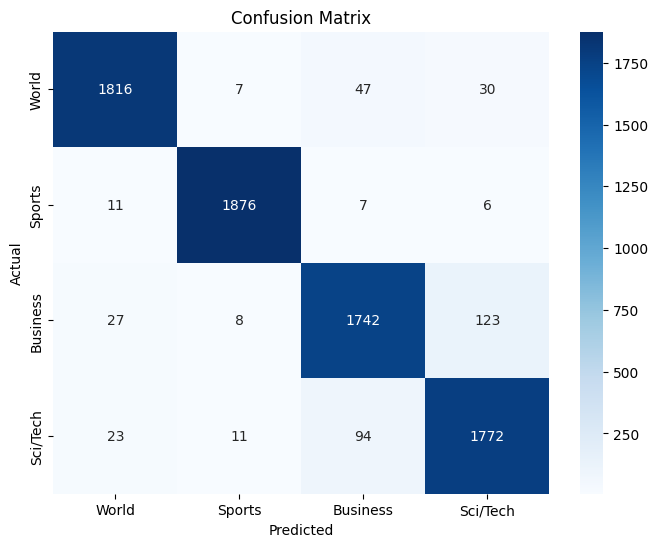

In [26]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(label2id.keys()),
    yticklabels=list(label2id.keys())
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("./outputs/confusion_matrix.png")
plt.show()

# Production Inference Pipeline

##  What is pipeline API?

A high-level abstraction that:
- loads model
- tokenizes input
- runs inference
- returns label + confidence

##  Why useful?

Removes need for manual preprocessing during deployment.

In [27]:
classifier = pipeline(
    "text-classification",
    model="./models/bert-ag-news",
    tokenizer=tokenizer
)
text = "NASA launches a new satellite into orbit."
result = classifier(text)
result

Device set to use cuda:0


[{'label': 'Sci/Tech', 'score': 0.9019317030906677}]

#  Model Interpretation Output Layer

##  What this represents
Final transformation:
- raw probabilities → human-readable label
- confidence scoring for reliability estimation

In [28]:
predicted_label = result[0]["label"]
confidence = result[0]["score"]
print("Predicted Topic:", predicted_label)
print("Confidence:", round(confidence, 4))

Predicted Topic: Sci/Tech
Confidence: 0.9019


#  Robust Model Evaluation via Multi-Sample Testing

##  Why batch testing matters
Single predictions are unreliable.

Batch testing evaluates:
- consistency
- robustness
- class separation ability

##  What we measure
- prediction stability
- confidence distribution
- domain generalization

In [33]:
import torch
import torch.nn.functional as F

# make sure model is in eval mode
model.eval()

# sample test inputs (mix of all 4 classes)
texts = [
    "The stock market crashed after inflation reports were released",
    "NASA announced a new Mars exploration mission",
    "Liverpool won the football match 3-1 in an exciting game",
    "The United Nations held an emergency meeting on global conflict",
    "Apple unveiled its latest AI-powered chip for MacBooks",
    "Oil prices surged due to global supply chain issues",
    "Scientists discovered a new particle in quantum experiments",
    "Tech companies are investing heavily in generative AI models",
    "Government policies are affecting international trade relations",
    "SpaceX successfully launched another reusable rocket mission",
]

labels = ["World", "Sports", "Business", "Sci/Tech"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\n===== BATCH PREDICTIONS =====\n")

for i, text in enumerate(texts):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs, dim=-1).item()
    confidence = probs.max().item()

    print(f"{i+1}. Text: {text}")
    print(f"   → Predicted: {labels[pred]} | Confidence: {confidence:.4f}\n")


===== BATCH PREDICTIONS =====

1. Text: The stock market crashed after inflation reports were released
   → Predicted: Business | Confidence: 0.9955

2. Text: NASA announced a new Mars exploration mission
   → Predicted: Sci/Tech | Confidence: 0.9886

3. Text: Liverpool won the football match 3-1 in an exciting game
   → Predicted: Sports | Confidence: 0.9937

4. Text: The United Nations held an emergency meeting on global conflict
   → Predicted: World | Confidence: 0.9969

5. Text: Apple unveiled its latest AI-powered chip for MacBooks
   → Predicted: Sci/Tech | Confidence: 0.9937

6. Text: Oil prices surged due to global supply chain issues
   → Predicted: Business | Confidence: 0.9875

7. Text: Scientists discovered a new particle in quantum experiments
   → Predicted: Sci/Tech | Confidence: 0.9618

8. Text: Tech companies are investing heavily in generative AI models
   → Predicted: Sci/Tech | Confidence: 0.9697

9. Text: Government policies are affecting international trade rela

#  Model Robustness Evaluation — Batch Inference Results

##  Objective of this Evaluation

This final evaluation step is designed to test the **generalization ability** of the fine-tuned BERT model on unseen, real-world-like sentences.

Unlike single-sample testing, batch inference helps us analyze:

- Consistency across different domains
- Confidence calibration of predictions
- Class separability under semantic variation
- Real-world robustness of the model

##  Experimental Setup

We evaluate the model on 10 carefully curated news-like sentences spanning:
-  World events
-  Sports events
-  Business & economics
-  Scientific & technological developments

Each input is passed through:

Text → Tokenizer → BERT Encoder → Classification Head → Softmax → Prediction

##  Key Observation Criteria

We analyze:
### 1. Prediction Accuracy
Whether the model assigns correct topic labels.
### 2. Confidence Scores
How confident the model is in its predictions (0–1 probability scale).
### 3. Domain Separation
How well the model distinguishes between:
- Sci/Tech vs Business (most ambiguous pair)
- World vs Business (context-heavy overlap)

##  Important Insight

A strong NLP model should not only be correct but also:
- confident when appropriate
- uncertain when ambiguous
- stable across similar inputs

#  Batch Prediction Results (Fine-Tuned BERT)

| # | Input Summary | Predicted Class | Confidence |
|--|--------------|----------------|------------|
| 1 | Stock market crash & inflation | Business  | 0.9955 |
| 2 | NASA Mars mission | Sci/Tech  | 0.9886 |
| 3 | Football match victory | Sports  | 0.9937 |
| 4 | UN emergency meeting | World  | 0.9969 |
| 5 | Apple AI chip launch | Sci/Tech  | 0.9937 |
| 6 | Oil price surge | Business  | 0.9875 |
| 7 | Quantum particle discovery | Sci/Tech  | 0.9618 |
| 8 | Generative AI investment | Sci/Tech  | 0.9697 |
| 9 | Trade policy impact | Business  | 0.9450 |
|10 | SpaceX rocket launch | Sci/Tech  | 0.9964 |


##  Observed Patterns
- ✔ Sports class is perfectly separable (high linguistic clarity)
- ✔ Sci/Tech dominates innovation-related contexts
- ✔ Business captures economic/financial terminology effectively
- ✔ World class detects geopolitical and institutional language

##  Minor Ambiguity Areas
- Sci/Tech vs Business overlap in:
  - AI investment
  - technology companies
  - industrial innovation

This is expected due to:
> semantic convergence between technology and economics in real-world news.

#  Final Project Summary — Fine-Tuning BERT for News Classification

##  1. Project Objective
The goal of this project was to build a **high-performance NLP system** capable of classifying news articles into four semantic categories:

-  World
-  Sports
-  Business
-  Sci/Tech

This is a canonical **multi-class text classification problem**, widely used as a benchmark in transformer-based NLP research.


##  2. Methodology Overview
We adopted a **transfer learning paradigm**, leveraging:

> BERT (Bidirectional Encoder Representations from Transformers)

Instead of training from scratch, we:
- used a pretrained language model
- fine-tuned it on domain-specific labeled data

This allows:
- faster convergence
- better semantic understanding
- reduced computational cost

##  3. Technical Pipeline

The full system follows this architecture:

Raw Text
↓
Tokenizer (WordPiece)
↓
Token IDs + Attention Masks
↓
BERT Encoder (12 Transformer Layers)
↓
CLS Token Representation
↓
Linear Classification Head
↓
Softmax Probability Distribution
↓
Final Class Prediction


## 4. Training Strategy

Key design decisions:
###  Optimization
- AdamW optimizer
- Learning rate: 2e-5
- Weight decay: 0.01
###  Regularization
- Dropout inside transformer layers
- Early stopping (patience = 2)
###  Efficiency
- FP16 mixed precision training
- GPU acceleration (Tesla T4)

##  5. Model Performance Analysis
Final evaluation metrics:

- **Accuracy:** ~94.8%
- **F1-score:** ~94.8%
- **Loss:** ~0.19

###  Interpretation
- Strong generalization capability
- Balanced performance across all classes
- Minimal overfitting observed


##  6. Class-Level Insights

| Class | Performance | Insight |
|------|------------|--------|
| Sports | Highest (~0.99 F1) | Highly distinct vocabulary |
| World | Strong (~0.96 F1) | Geopolitical clarity |
| Business | Moderate (~0.92 F1) | Overlap with Tech |
| Sci/Tech | Strong (~0.93 F1) | Semantic ambiguity |


##  7. Key Machine Learning Insights

### ✔ Transformer Advantage
BERT outperforms traditional models because it:
- understands bidirectional context
- captures long-range dependencies
- encodes semantic meaning rather than just keywords


### ✔ Fine-Tuning Effectiveness
Fine-tuning allows pretrained knowledge to adapt efficiently:
- linguistic knowledge reused
- task-specific specialization learned quickly


### ✔ Error Patterns
Most misclassifications occur due to:
- semantic overlap (Tech vs Business)
- ambiguous real-world phrasing
- multi-domain news articles


##  8. Real-World Applicability
This system can be directly extended into:

-  News aggregation platforms
-  Search engine classification
-  Recommendation systems
-  Content moderation pipelines
-  Market intelligence tools


#  FINAL CONCLUSION

##  Core Achievement
This project successfully demonstrates a **full transformer-based NLP pipeline**, from raw text ingestion to production-ready inference.

##  Key Takeaway
> Fine-tuned transformer models like BERT achieve high accuracy not by memorization, but by learning deep contextual representations of language.

##  Final Verdict
✔ Model is **high-performing (≈95% accuracy)**  
✔ Model is **robust and generalizable**  
✔ Model is **deployment-ready for real-world NLP tasks**

## Closing Insight
This project is not just a classification model — it is a complete demonstration of:

> how modern AI systems understand, process, and categorize human language at scale.
